In [20]:
# Imports and repo setup.
from pathlib import Path
from collections import Counter
from dataclasses import asdict, dataclass
from io import BytesIO
import json
import os
import sys
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import numpy as np
import torch

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "calvin_experiments" / "calvin_rollout_utils.py").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find guided-diffusion repo root")
    REPO_ROOT = REPO_ROOT.parent

for path in [REPO_ROOT, REPO_ROOT / "robomimic", REPO_ROOT / "calvin" / "calvin_env", REPO_ROOT / "calvin_experiments"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import robomimic.envs  # noqa: F401
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils
import robomimic.utils.torch_utils as TorchUtils

from calvin_experiments import calvin_rollout_utils as CRU
from calvin_experiments.label_calvin_world_model import label_scene_states_for_names
from calvin_experiments.train_dynamics_world_model import load_dynamics_model_for_eval

print("repo:", REPO_ROOT)
print("cuda:", torch.cuda.is_available())


repo: /home/moritz/src/guided-diffusion
cuda: True


In [21]:
# Load the policy, automaton model, and local dynamics world model for optional safety guidance.
DEVICE = TorchUtils.get_torch_device(try_to_use_cuda=True)

POLICY_CKPT_PATH = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth"
AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38"
SCENE_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/blocks_hidden.json"
VISUALIZATION_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/visualization_freiburg_style.json"
DYNAMICS_CKPT_PATH = REPO_ROOT / "outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08"
OUTPUT_ROOT = REPO_ROOT / "outputs/calvin/paper_stls/G_cyclic_drawer_switch"
VIDEO_FPS = 30

policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=str(POLICY_CKPT_PATH), device=DEVICE, verbose=False)
policy_epoch = CRU.policy_epoch_from_checkpoint(POLICY_CKPT_PATH)
scene_cfg = CRU.load_json_config(SCENE_CONFIG_PATH)
video_cfg = CRU.load_json_config(VISUALIZATION_CONFIG_PATH)

automaton_model, automaton_stats, automaton_meta = CRU.automaton_model_for_eval(AUTOMATON_CKPT_PATH, DEVICE)
label_names = list(automaton_meta["label_names"])
label_thresholds = automaton_meta.get("label_thresholds")

dynamics_model, dynamics_stats, dynamics_ckpt, dynamics_meta = load_dynamics_model_for_eval(DYNAMICS_CKPT_PATH, device=DEVICE)
dynamics_model.eval()
dynamics_stats_t = {k: torch.as_tensor(v, device=DEVICE, dtype=torch.float32).unsqueeze(0) for k, v in dynamics_stats.items()}

OPPOSITE_LABEL_NAMES = {
    "switch_on": "switch_off", "switch_off": "switch_on",
    "button_on": "button_off", "button_off": "button_on",
    "drawer_open": "drawer_closed", "drawer_closed": "drawer_open",
    "door_left": "door_right", "door_right": "door_left",
}

def validate_target_label_idx(target_label_idx):
    target_label_idx = int(target_label_idx)
    if target_label_idx < 0 or target_label_idx >= len(label_names):
        raise ValueError(f"target_label_idx must be in [0, {len(label_names) - 1}], got {target_label_idx}")
    return target_label_idx

def opposite_label_idx(target_label_idx):
    target_label_idx = validate_target_label_idx(target_label_idx)
    opposite_name = OPPOSITE_LABEL_NAMES.get(label_names[target_label_idx])
    if opposite_name is None or opposite_name not in label_names:
        return None
    return label_names.index(opposite_name)

def score_label_probs(label_probs, target_label_idx):
    target_label_idx = validate_target_label_idx(target_label_idx)
    scores = np.asarray(label_probs, dtype=np.float32)[..., target_label_idx].copy()
    opp = opposite_label_idx(target_label_idx)
    if opp is not None:
        scores -= np.asarray(label_probs, dtype=np.float32)[..., opp]
    return scores

def score_rule_name(target_label_idx):
    target_label_idx = validate_target_label_idx(target_label_idx)
    opp = opposite_label_idx(target_label_idx)
    if opp is None:
        return f"p({label_names[target_label_idx]})"
    return f"p({label_names[target_label_idx]}) - p({label_names[opp]})"

print("device:", DEVICE)
print("policy:", POLICY_CKPT_PATH)
print("automaton:", AUTOMATON_CKPT_PATH)
print("dynamics:", DYNAMICS_CKPT_PATH)
print("label order:")
for idx, name in enumerate(label_names):
    print(f"  {idx}: {name}  score={score_rule_name(idx)}")



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['proprio']
using obs modality: rgb with keys: ['third_person', 'eye_in_hand']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.931892e+07
device: cuda:0
policy: /home/moritz/src/guided-diffusion/outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth
automaton: /home/moritz/src/guided-diffusion/outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38
dynamics: /home/moritz/src/guided-diffusion/outputs/calvin/dynamics_world_model/hd512_depth4_drop0.02_lr0.0005_epochs70_2026-05-06_01-42-08
label order:
  0: switch_on  score=p(switch_on) - p(switch_off)
  1: switch_off  score=p(switch_off) - p(switch_on)
  2: button_on  score=p(button_on) - p(button_off)
  3: button_off  score=p(button_off) - p(button_on)
  4: button_pressed  score=p(button_pressed)
  5

In [22]:
# Rollout helpers and automaton sample-and-rank utilities.
env = None
base_env_state = None

def current_automaton_state_and_label(env):
    state = env.get_state()
    robot = np.asarray(state["robot"], dtype=np.float32).reshape(-1)
    scene = np.asarray(state["scene"], dtype=np.float32).reshape(-1)
    automaton_state = np.concatenate([robot, scene]).astype(np.float32)
    automaton_label = label_scene_states_for_names(scene[None, :], label_names, label_thresholds)[0].astype(np.float32)
    return automaton_state, automaton_label

def repeat_obs_batch(obs_tensor, n):
    if int(n) == 1:
        return obs_tensor
    return {key: value.repeat((int(n),) + (1,) * (value.ndim - 1)) for key, value in obs_tensor.items()}

def unnormalize_action_sequence(action_sequence):
    action_np = CRU.to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np
    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {key: policy.action_normalization_stats[key]["offset"].shape[1:] for key in policy.action_normalization_stats}
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)

def predict_future_label_probs(automaton_state, automaton_label, action_chunks):
    action_chunks = np.asarray(action_chunks, dtype=np.float32)
    n_candidates, _, action_dim = action_chunks.shape
    automaton_horizon = len(automaton_stats["actions_mean"]) // action_dim
    scored_chunks = action_chunks[:, :automaton_horizon, :].reshape(n_candidates, -1)
    states = np.repeat(np.asarray(automaton_state, dtype=np.float32)[None, :], n_candidates, axis=0)
    labels = np.repeat(np.asarray(automaton_label, dtype=np.float32)[None, :], n_candidates, axis=0)
    states_t = torch.as_tensor((states - automaton_stats["states_mean"]) / automaton_stats["states_std"], device=DEVICE, dtype=torch.float32)
    actions_t = torch.as_tensor((scored_chunks - automaton_stats["actions_mean"]) / automaton_stats["actions_std"], device=DEVICE, dtype=torch.float32)
    labels_t = torch.as_tensor(labels, device=DEVICE, dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(automaton_model(states_t, actions_t, labels_t)).detach().cpu().numpy()
    return probs, automaton_horizon

def rollout_policy_once(seed, action_sampler, output_dir, rollout_tag, horizon=3000, save_video=True):
    global env, base_env_state
    CRU.drop_env_quietly(globals(), name="env")
    env, base_env_state = CRU.load_fresh_env_from_checkpoint(ckpt_dict, seed=int(seed), suppress_output=True)
    fixed_scene, fixed_robot, active_scene_cfg = CRU.fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH)

    CRU.seed_everything(seed)
    policy.start_episode()
    obs = CRU.reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
    scene_snapshot = CRU.capture_scene_snapshot(env)
    frames = [CRU.render_visual_camera(env, video_cfg)] if save_video else []

    start_state = env.get_state()
    start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
    binaries = CRU.articulated_binaries_from_start_state(start_scene)
    _, label0 = current_automaton_state_and_label(env)
    if hasattr(action_sampler, "sync"):
        action_sampler.sync(label0, 0)

    actions, rewards, dones, records = [], [], [], []
    target_events = []
    scene_states = [start_scene.copy()]
    robot_states = [np.asarray(start_state["robot"], dtype=np.float32).copy()]
    eef_xy = [robot_states[-1][:2].copy()]
    action_queue = []
    first_behavior, first_behavior_step = "none", -1
    termination_reason = "horizon"

    for step in range(int(horizon)):
        if getattr(action_sampler, "timed_out", False):
            termination_reason = "target_timeout"
            break
        if getattr(action_sampler, "done", False):
            termination_reason = "max_cycle_events"
            break

        if not action_queue:
            new_actions, record = action_sampler(obs, env, step)
            action_queue.extend(np.asarray(new_actions, dtype=np.float32))
            records.append(record)
        action = np.asarray(action_queue.pop(0), dtype=np.float32).copy()
        actions.append(action.copy())

        obs, reward, done, _ = env.step(action)
        state = env.get_state()
        scene = np.asarray(state["scene"], dtype=np.float32).copy()
        robot = np.asarray(state["robot"], dtype=np.float32).copy()
        _, current_label = current_automaton_state_and_label(env)

        rewards.append(float(reward)); dones.append(bool(done))
        scene_states.append(scene); robot_states.append(robot); eef_xy.append(robot[:2].copy())
        if save_video:
            frames.append(CRU.render_visual_camera(env, video_cfg))

        if first_behavior_step < 0 and CRU.check_state_difference(start_scene, scene, robot[:3], binaries, for_display=False):
            first_behavior = CRU.classify_behavior(start_scene, scene, robot[:3], binaries, for_display=False)
            first_behavior_step = step + 1

        if hasattr(action_sampler, "sync"):
            events_before = len(action_sampler.events)
            advanced = action_sampler.sync(current_label, step + 1)
            if advanced:
                action_queue.clear()
                target_events.extend(action_sampler.events[events_before:])
            if getattr(action_sampler, "timed_out", False):
                termination_reason = "target_timeout"
                break
            if getattr(action_sampler, "done", False):
                termination_reason = "max_cycle_events"
                break
        if done:
            termination_reason = "env_done"
            break

    _, labelf = current_automaton_state_and_label(env)
    behavior_step = int(target_events[-1]["step"] if target_events else first_behavior_step)
    rollout = {
        "scene_config": active_scene_cfg["name"], "seed": int(seed),
        "behavior": "cyclic_ltl", "first_behavior": first_behavior, "first_behavior_step": int(first_behavior_step),
        "behavior_step": behavior_step,
        "termination_step": len(actions), "termination_reason": termination_reason,
        "cycles_completed": int(getattr(action_sampler, "cycles_completed", 0)),
        "cycle_pos": int(getattr(action_sampler, "cycle_pos", 0)),
        "current_target_name": getattr(action_sampler, "current_target_name", None),
        "target_elapsed": int(getattr(action_sampler, "target_elapsed", 0)),
        "return": float(np.sum(rewards)), "actions": np.asarray(actions, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32), "dones": np.asarray(dones, dtype=bool),
        "scene_states": np.asarray(scene_states, dtype=np.float32), "robot_states": np.asarray(robot_states, dtype=np.float32),
        "eef_xy": np.asarray(eef_xy, dtype=np.float32), "initial_label": label0.astype(int).tolist(),
        "final_label": labelf.astype(int).tolist(), "records": records, "target_events": target_events,
        "timed_out": bool(getattr(action_sampler, "timed_out", False)),
        "timeout_event": getattr(action_sampler, "timeout_event", None),
        "scene_snapshot": scene_snapshot,
    }
    if save_video:
        CRU.save_rollout_artifacts(rollout, frames, output_dir, rollout_tag, video_cfg, fps=VIDEO_FPS)
    return rollout


In [23]:
# Optional local-dynamics safety guidance for avoiding one or more EEF XY boxes.
@dataclass
class SafetyBox:
    x_min: float = 0.24
    x_max: float = 0.29
    y_min: float = -0.15
    y_max: float = -0.10
    margin: float = 0.005

    def normalized(self):
        return SafetyBox(
            min(self.x_min, self.x_max), max(self.x_min, self.x_max),
            min(self.y_min, self.y_max), max(self.y_min, self.y_max),
            float(max(self.margin, 0.0)),
        )

def normalize_safety_boxes(safety_boxes):
    if safety_boxes is None:
        return []
    if isinstance(safety_boxes, SafetyBox):
        return [safety_boxes.normalized()]
    return [box.normalized() for box in safety_boxes]

def euler_xyz_to_rot6d_torch(euler_xyz):
    x, y, z = euler_xyz[..., 0], euler_xyz[..., 1], euler_xyz[..., 2]
    sx, cx = torch.sin(x), torch.cos(x)
    sy, cy = torch.sin(y), torch.cos(y)
    sz, cz = torch.sin(z), torch.cos(z)
    return torch.stack([cz * cy, sz * cy, -sy, cz * sy * sx - sz * cx, sz * sy * sx + cz * cx, cy * sx], dim=-1)

def raw_env_state_to_dynamics_state_torch(robot, scene):
    robot_t = torch.as_tensor(robot, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    scene_t = torch.as_tensor(scene, device=DEVICE, dtype=torch.float32).reshape(1, -1)
    robot_dyn = torch.cat([robot_t[..., :3], euler_xyz_to_rot6d_torch(robot_t[..., 3:6]), robot_t[..., 6:]], dim=-1)
    scene_parts = [scene_t[..., :6]]
    for start in (6, 12, 18):
        scene_parts += [scene_t[..., start:start + 3], euler_xyz_to_rot6d_torch(scene_t[..., start + 3:start + 6])]
    return torch.cat([robot_dyn, torch.cat(scene_parts, dim=-1)], dim=-1)

def project_rot6d_torch(rot6d):
    r1 = rot6d[..., 0:3]
    r2 = rot6d[..., 3:6]
    r1 = r1 / (torch.linalg.norm(r1, dim=-1, keepdim=True) + 1e-8)
    r2 = r2 - torch.sum(r1 * r2, dim=-1, keepdim=True) * r1
    r2 = r2 / (torch.linalg.norm(r2, dim=-1, keepdim=True) + 1e-8)
    return torch.cat([r1, r2], dim=-1)

def project_dynamics_state_torch(state):
    pieces, cursor = [], 0
    for start, end in [(3, 9), (27, 33), (36, 42), (45, 51)]:
        pieces += [state[..., cursor:start], project_rot6d_torch(state[..., start:end])]
        cursor = end
    return torch.cat(pieces + [state[..., cursor:]], dim=-1)

def dynamics_rollout_torch(state_dyn, action_chunk):
    if action_chunk.ndim == 2:
        action_chunk = action_chunk.unsqueeze(0)
    state = state_dyn.expand(action_chunk.shape[0], -1)
    states = []
    for t in range(action_chunk.shape[1]):
        state_n = (state - dynamics_stats_t["state_mean"]) / dynamics_stats_t["state_std"]
        action_n = (action_chunk[:, t, :] - dynamics_stats_t["action_mean"]) / dynamics_stats_t["action_std"]
        delta_n = dynamics_model(state_n, action_n)
        delta = delta_n * dynamics_stats_t["delta_std"] + dynamics_stats_t["delta_mean"]
        state = project_dynamics_state_torch(state + delta)
        states.append(state)
    return torch.stack(states, dim=1)

def signed_distance_to_box_torch(xy, safety_box):
    box = safety_box.normalized()
    center = torch.tensor([(box.x_min + box.x_max) / 2, (box.y_min + box.y_max) / 2], device=xy.device, dtype=xy.dtype)
    half = torch.tensor([(box.x_max - box.x_min) / 2, (box.y_max - box.y_min) / 2], device=xy.device, dtype=xy.dtype)
    q = torch.abs(xy - center) - half
    outside = torch.linalg.norm(torch.clamp(q, min=0.0), dim=-1)
    inside = torch.minimum(torch.maximum(q[..., 0], q[..., 1]), torch.zeros((), device=xy.device, dtype=xy.dtype))
    return outside + inside

def signed_distance_to_boxes_torch(xy, safety_boxes):
    boxes = normalize_safety_boxes(safety_boxes)
    if not boxes:
        return torch.full(xy.shape[:-1], 1e6, device=xy.device, dtype=xy.dtype)
    per_box = torch.stack([signed_distance_to_box_torch(xy, box) for box in boxes], dim=-1)
    return per_box.min(dim=-1).values

def safety_robustness_torch(state_dyn, action_chunk, safety_boxes, smooth_min_tau=0.02):
    boxes = normalize_safety_boxes(safety_boxes)
    pred_states = dynamics_rollout_torch(state_dyn, action_chunk)
    pred_xy = pred_states[..., 0:2]
    signed_dist = signed_distance_to_boxes_torch(pred_xy, boxes)
    margin = max([box.margin for box in boxes], default=0.0)
    capped = torch.clamp(signed_dist, max=float(margin))
    tau = max(float(smooth_min_tau), 1e-6)
    smooth_min = -tau * torch.logsumexp(-capped / tau, dim=-1)
    return smooth_min, pred_xy, signed_dist

def refine_action_chunk_for_safety(robot, scene, action_chunk, safety_boxes, guidance_scale=0.5, gradient_steps=5, step_size=0.03, action_reg=0.05, smooth_min_tau=0.02):
    state_dyn = raw_env_state_to_dynamics_state_torch(robot, scene)
    original = torch.as_tensor(action_chunk[None], device=DEVICE, dtype=torch.float32)
    with torch.no_grad():
        robust_before, pred_xy_before, signed_before = safety_robustness_torch(state_dyn, original, safety_boxes, smooth_min_tau)

    if float(guidance_scale) <= 0.0 or int(gradient_steps) <= 0:
        record = {
            "robust_before": float(robust_before[0].cpu()), "robust_after": float(robust_before[0].cpu()),
            "min_signed_dist_before": float(signed_before[0].min().cpu()), "min_signed_dist_after": float(signed_before[0].min().cpu()),
            "pred_xy_before": pred_xy_before[0].detach().cpu().numpy().tolist(), "pred_xy_after": pred_xy_before[0].detach().cpu().numpy().tolist(),
            "action_l2_change": 0.0, "history": [],
        }
        return np.asarray(action_chunk, dtype=np.float32), record

    actions = original.clone().detach().requires_grad_(True)
    opt = torch.optim.Adam([actions], lr=float(step_size))
    history = []
    for _ in range(int(gradient_steps)):
        opt.zero_grad(set_to_none=True)
        robust, _, _ = safety_robustness_torch(state_dyn, actions, safety_boxes, smooth_min_tau)
        action_penalty = torch.mean((actions - original) ** 2, dim=(1, 2))
        objective = float(guidance_scale) * robust - float(action_reg) * action_penalty
        (-objective.mean()).backward()
        opt.step()
        with torch.no_grad():
            actions.clamp_(-1.0, 1.0)
            history.append({"robustness": float(robust[0].detach().cpu()), "action_penalty": float(action_penalty[0].detach().cpu()), "objective": float(objective[0].detach().cpu())})
    with torch.no_grad():
        robust_after, pred_xy_after, signed_after = safety_robustness_torch(state_dyn, actions, safety_boxes, smooth_min_tau)
    record = {
        "robust_before": float(robust_before[0].cpu()), "robust_after": float(robust_after[0].cpu()),
        "min_signed_dist_before": float(signed_before[0].min().cpu()), "min_signed_dist_after": float(signed_after[0].min().cpu()),
        "pred_xy_before": pred_xy_before[0].detach().cpu().numpy().tolist(), "pred_xy_after": pred_xy_after[0].detach().cpu().numpy().tolist(),
        "action_l2_change": float(torch.linalg.norm(actions - original).detach().cpu()), "history": history,
    }
    return actions[0].detach().cpu().numpy().astype(np.float32), record

def path_enters_safety_boxes(eef_xy, safety_boxes):
    xy = np.asarray(eef_xy, dtype=np.float32)
    for box in normalize_safety_boxes(safety_boxes):
        if np.any((xy[:, 0] >= box.x_min) & (xy[:, 0] <= box.x_max) & (xy[:, 1] >= box.y_min) & (xy[:, 1] <= box.y_max)):
            return True
    return False


In [24]:
# Cyclic LTL sampler: repeatedly optimize drawer_open -> switch_on -> drawer_closed -> switch_off.
def target_cycle_from_names(target_names):
    missing = [name for name in target_names if name not in label_names]
    if missing:
        raise ValueError(f"Targets not in loaded automaton labels: {missing}; labels={label_names}")
    return [label_names.index(name) for name in target_names]

def make_cyclic_sample_rank_action_provider(target_cycle, n_candidates, target_timeout_steps=300, max_target_events=10, use_safety_guidance=False, safety_box=None, safety_guidance_scale=0.5, safety_gradient_steps=5, safety_step_size=0.03, safety_action_reg=0.05, safety_smooth_min_tau=0.02):
    target_cycle = [validate_target_label_idx(idx) for idx in target_cycle]
    n_candidates = int(n_candidates)
    target_timeout_steps = int(target_timeout_steps)
    max_target_events = int(max_target_events)
    if use_safety_guidance and safety_box is None:
        raise ValueError("safety_box must be set when use_safety_guidance=True")
    state = {"pos": 0, "events": [], "target_start_step": 0, "cycles_completed": 0, "timed_out": False, "timeout_event": None}

    def refresh_public(step):
        action_provider.cycle_pos = int(state["pos"])
        action_provider.cycles_completed = int(state["cycles_completed"])
        action_provider.events = state["events"]
        action_provider.done = len(state["events"]) >= max_target_events
        action_provider.timed_out = bool(state["timed_out"])
        action_provider.timeout_event = state["timeout_event"]
        action_provider.current_target_idx = int(target_cycle[state["pos"]])
        action_provider.current_target_name = label_names[target_cycle[state["pos"]]]
        action_provider.target_elapsed = int(step - state["target_start_step"])

    def sync(label, step):
        advanced = False
        if state["timed_out"] or len(state["events"]) >= max_target_events:
            refresh_public(step)
            return False

        while len(state["events"]) < max_target_events:
            target_idx = target_cycle[state["pos"]]
            if float(label[target_idx]) <= 0.5:
                break
            elapsed = int(step - state["target_start_step"])
            event = {
                "step": int(step), "elapsed": elapsed,
                "event_idx": len(state["events"]), "cycle_idx": int(state["cycles_completed"]),
                "cycle_pos": int(state["pos"]), "target_idx": int(target_idx), "target_name": label_names[target_idx],
            }
            state["events"].append(event)
            state["pos"] = (state["pos"] + 1) % len(target_cycle)
            if state["pos"] == 0:
                state["cycles_completed"] += 1
            state["target_start_step"] = int(step)
            advanced = True

        if len(state["events"]) < max_target_events:
            elapsed = int(step - state["target_start_step"])
            if elapsed >= target_timeout_steps:
                target_idx = target_cycle[state["pos"]]
                state["timed_out"] = True
                state["timeout_event"] = {
                    "step": int(step), "elapsed": elapsed,
                    "cycle_idx": int(state["cycles_completed"]), "cycle_pos": int(state["pos"]),
                    "target_idx": int(target_idx), "target_name": label_names[target_idx],
                    "message": f"target not reached within {target_timeout_steps} steps",
                }
        refresh_public(step)
        return advanced

    def action_provider(obs, env, step):
        automaton_state, automaton_label = current_automaton_state_and_label(env)
        sync(automaton_label, step)
        target_label_idx = target_cycle[state["pos"]]

        obs_tensor = policy._prepare_observation(obs)
        obs_tensor_rank = repeat_obs_batch(obs_tensor, n_candidates)
        with torch.no_grad():
            action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
        action_chunks = unnormalize_action_sequence(action_chunk_n)
        candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunks)
        candidate_scores = score_label_probs(candidate_probs, target_label_idx)
        selected_idx = int(np.argmax(candidate_scores))
        selected = np.asarray(action_chunks[selected_idx, :automaton_horizon, :], dtype=np.float32)
        safety_record = None
        if use_safety_guidance:
            env_state = env.get_state()
            selected, safety_record = refine_action_chunk_for_safety(
                env_state["robot"], env_state["scene"], selected, safety_box,
                guidance_scale=safety_guidance_scale, gradient_steps=safety_gradient_steps,
                step_size=safety_step_size, action_reg=safety_action_reg, smooth_min_tau=safety_smooth_min_tau,
            )
        opp = opposite_label_idx(target_label_idx)
        record = {
            "t": int(step), "mode": "cyclic_ltl", "cycle_names": [label_names[idx] for idx in target_cycle],
            "cycle_pos": int(state["pos"]), "cycle_idx": int(state["cycles_completed"]),
            "event_count": len(state["events"]), "target_elapsed": int(step - state["target_start_step"]),
            "target_label_idx": int(target_label_idx), "target_label_name": label_names[target_label_idx],
            "opposite_label_idx": None if opp is None else int(opp),
            "opposite_label_name": None if opp is None else label_names[opp],
            "score_rule": score_rule_name(target_label_idx), "current_label": automaton_label.astype(int).tolist(),
            "selected_idx": selected_idx, "selected_score": float(candidate_scores[selected_idx]),
            "selected_target_prob": float(candidate_probs[selected_idx, target_label_idx]),
            "selected_opposite_prob": None if opp is None else float(candidate_probs[selected_idx, opp]),
            "pred_probs": candidate_probs[selected_idx].tolist(), "candidate_scores": candidate_scores.tolist(),
            "safety": safety_record,
        }
        return selected, record

    action_provider.sync = sync
    action_provider.cycle_pos = 0
    action_provider.cycles_completed = 0
    action_provider.events = state["events"]
    action_provider.done = False
    action_provider.timed_out = False
    action_provider.timeout_event = None
    action_provider.current_target_idx = int(target_cycle[0])
    action_provider.current_target_name = label_names[target_cycle[0]]
    action_provider.target_elapsed = 0
    action_provider.use_safety_guidance = bool(use_safety_guidance)
    return action_provider


In [25]:
# Experiment knobs and rollout loop. Finite rollouts approximate G by repeating the cycle until stopped.
SEEDS = [1]
TARGET_CYCLE_NAMES = ["drawer_open", "switch_on", "drawer_closed", "switch_off"]
TARGET_CYCLE_NAMES = ["button_pressed", "door_left", "button_pressed", "door_right"]
TARGET_CYCLE = target_cycle_from_names(TARGET_CYCLE_NAMES)
N_CANDIDATES = 32
TARGET_TIMEOUT_STEPS = 300
MAX_TARGET_EVENTS = 32
HORIZON = TARGET_TIMEOUT_STEPS * MAX_TARGET_EVENTS
SAVE_VIDEO = True

USE_SAFETY_GUIDANCE = False
SAFETY_BOXES = [
    SafetyBox(x_min=0.23, x_max=0.26, y_min=-0.12, y_max=-0.09, margin=0.010),
    # SafetyBox(x_min=0.31, x_max=0.35, y_min=-0.090, y_max=-0.050, margin=0.010),
]
SAFETY_GUIDANCE_SCALE = 10.0
SAFETY_GRADIENT_STEPS = 10
SAFETY_STEP_SIZE = 0.05
SAFETY_ACTION_REG = 0.03
SAFETY_SMOOTH_MIN_TAU = 0.01

run_dir = OUTPUT_ROOT / time.strftime("%Y%m%d_%H%M%S")
run_dir.mkdir(parents=True, exist_ok=False)

rollouts = []
for seed in SEEDS:
    action_sampler = make_cyclic_sample_rank_action_provider(
        TARGET_CYCLE, N_CANDIDATES,
        target_timeout_steps=TARGET_TIMEOUT_STEPS,
        max_target_events=MAX_TARGET_EVENTS,
        use_safety_guidance=USE_SAFETY_GUIDANCE,
        safety_box=SAFETY_BOXES,
        safety_guidance_scale=SAFETY_GUIDANCE_SCALE,
        safety_gradient_steps=SAFETY_GRADIENT_STEPS,
        safety_step_size=SAFETY_STEP_SIZE,
        safety_action_reg=SAFETY_ACTION_REG,
        safety_smooth_min_tau=SAFETY_SMOOTH_MIN_TAU,
    )
    rollout = rollout_policy_once(
        seed=seed,
        action_sampler=action_sampler,
        output_dir=run_dir,
        rollout_tag=f"cycle_{'_then_'.join(TARGET_CYCLE_NAMES)}_seed_{seed:03d}",
        horizon=HORIZON,
        save_video=SAVE_VIDEO,
    )
    rollout["safety_violation"] = path_enters_safety_boxes(rollout["eef_xy"], SAFETY_BOXES) if USE_SAFETY_GUIDANCE else False
    rollouts.append(rollout)
    event_str = ", ".join(f"{e['target_name']}@{e['step']}" for e in rollout["target_events"])
    print(
        f"seed {seed:03d}: reason={rollout['termination_reason']}, cycles={rollout['cycles_completed']}, "
        f"events={len(rollout['target_events'])}, current={rollout['current_target_name']} elapsed={rollout['target_elapsed']}, "
        f"safe={not rollout['safety_violation']}, sequence=[{event_str}], timeout={rollout['timeout_event']}, video={rollout.get('video')}"
    )

summary = {
    "formula": "G F(drawer_open -> F switch_on -> F drawer_closed -> F switch_off), finite cyclic approximation",
    "target_cycle_names": TARGET_CYCLE_NAMES, "target_cycle": TARGET_CYCLE,
    "score_rules": [score_rule_name(idx) for idx in TARGET_CYCLE],
    "seeds": SEEDS, "n_candidates": N_CANDIDATES, "horizon": HORIZON,
    "target_timeout_steps": TARGET_TIMEOUT_STEPS, "max_target_events": MAX_TARGET_EVENTS,
    "use_safety_guidance": USE_SAFETY_GUIDANCE,
    "safety_boxes": [asdict(box) for box in normalize_safety_boxes(SAFETY_BOXES)] if USE_SAFETY_GUIDANCE else None,
    "safety_guidance": {"scale": SAFETY_GUIDANCE_SCALE, "gradient_steps": SAFETY_GRADIENT_STEPS, "step_size": SAFETY_STEP_SIZE, "action_reg": SAFETY_ACTION_REG, "smooth_min_tau": SAFETY_SMOOTH_MIN_TAU} if USE_SAFETY_GUIDANCE else None,
    "n_rollouts": len(rollouts),
    "mean_cycles_completed": float(np.mean([r["cycles_completed"] for r in rollouts])) if rollouts else 0.0,
    "termination_counts": dict(Counter(r["termination_reason"] for r in rollouts)),
    "safe_rate": sum(not r.get("safety_violation", False) for r in rollouts) / max(1, len(rollouts)),
    "event_count_distribution": dict(Counter(len(r["target_events"]) for r in rollouts)),
    "rollouts": [
        {
            "seed": r["seed"], "termination_step": r["termination_step"], "termination_reason": r["termination_reason"],
            "cycles_completed": r["cycles_completed"], "cycle_pos": r["cycle_pos"],
            "current_target_name": r["current_target_name"], "target_elapsed": r["target_elapsed"],
            "target_events": r["target_events"], "timeout_event": r["timeout_event"],
            "safety_violation": r.get("safety_violation", False),
            "initial_label": r["initial_label"], "final_label": r["final_label"],
            "video": None if "video" not in r else str(r["video"]), "trace": None if "trace" not in r else str(r["trace"]),
        }
        for r in rollouts
    ],
}
(run_dir / "summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("run_dir:", run_dir)


ven = NVIDIA Corporation
ven = NVIDIA Corporation
ObservationKeyToModalityDict: states not found, adding states to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: actions not found, adding actions to mapping with assumed low_dim modality!
seed 001: reason=target_timeout, cycles=0, events=1, current=door_left elapsed=300, safe=True, sequence=[button_pressed@28], timeout={'step': 328, 'elapsed': 300, 'cycle_idx': 0, 'cycle_pos': 1, 'target_idx': 7, 'target_name': 'door_left', 'message': 'target not reached within 300 steps'}, video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/G_cyclic_drawer_switch/20260521_015643/cycle_button_pressed_then_door_left_then_button_pressed_then_door_right_seed_001/blocks_hidden_cycle_button_pressed_then_door_left_then_button_pressed_then_door_right_seed_001_freiburg_style.mp4
{
  "formula": "G F(drawer_open -> F sw

plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/G_cyclic_drawer_switch/20260521_015201/rollouts_xy_time_gradient.png


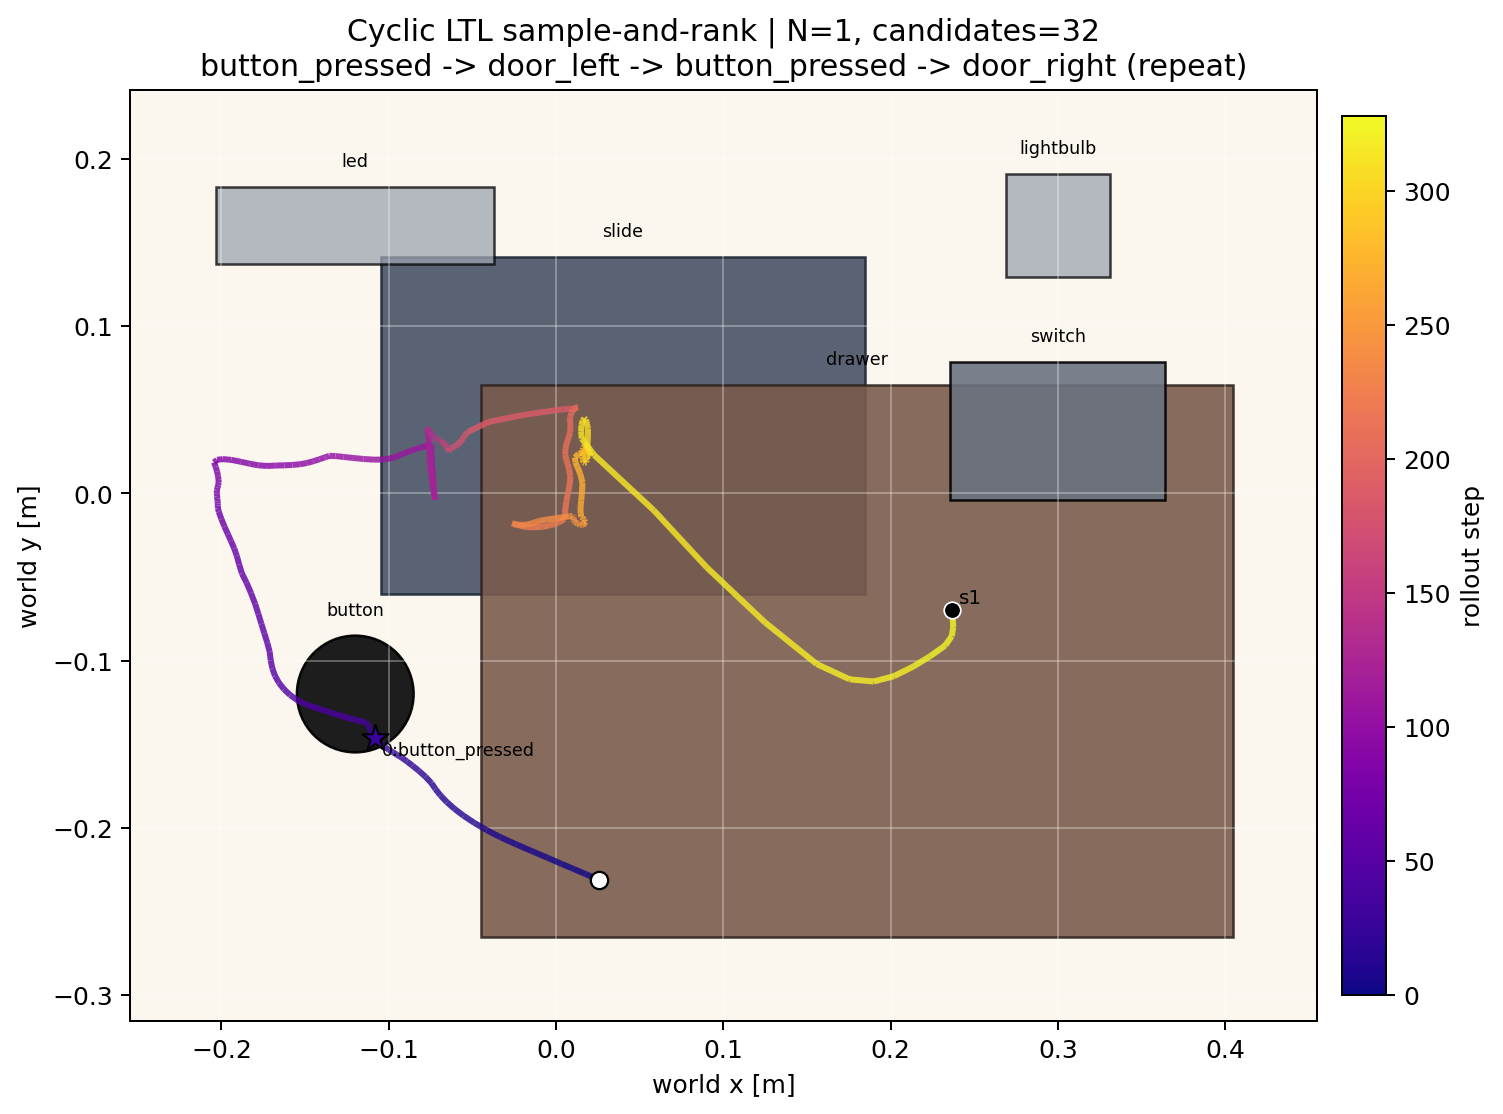

first selected chunks:
{'seed': 1, 't': 0, 'cycle_idx': 0, 'cycle_pos': 0, 'event_count': 0, 'target_elapsed': 0, 'target': 'button_pressed', 'score_rule': 'p(button_pressed)', 'score': 0.2685396671295166, 'target_prob': 0.2685396671295166, 'opposite_prob': None, 'safety_min_before': None, 'safety_min_after': None}
{'seed': 1, 't': 8, 'cycle_idx': 0, 'cycle_pos': 0, 'event_count': 0, 'target_elapsed': 8, 'target': 'button_pressed', 'score_rule': 'p(button_pressed)', 'score': 0.45882582664489746, 'target_prob': 0.45882582664489746, 'opposite_prob': None, 'safety_min_before': None, 'safety_min_after': None}
{'seed': 1, 't': 16, 'cycle_idx': 0, 'cycle_pos': 0, 'event_count': 0, 'target_elapsed': 16, 'target': 'button_pressed', 'score_rule': 'p(button_pressed)', 'score': 0.5235750675201416, 'target_prob': 0.5235750675201416, 'opposite_prob': None, 'safety_min_before': None, 'safety_min_after': None}
{'seed': 1, 't': 24, 'cycle_idx': 0, 'cycle_pos': 0, 'event_count': 0, 'target_elapsed': 24

In [19]:
# Plot cyclic rollout paths with event markers and inspect selected targets per chunk.
from matplotlib.collections import LineCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from IPython.display import Image, display
import matplotlib.pyplot as plt

def plot_cyclic_rollout_xy(rollouts, scene_snapshot, title, save_path=None, cmap_name="plasma", safety_boxes=None, draw_safety_region=False):
    paths = [np.asarray(r["eef_xy"], dtype=np.float32) for r in rollouts]
    max_step = max(max(1, len(path) - 1) for path in paths)
    norm = Normalize(vmin=0, vmax=max_step)
    cmap = plt.get_cmap(cmap_name)
    marker_by_name = {"drawer_open": "*", "switch_on": "P", "drawer_closed": "X", "switch_off": "D"}

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_facecolor("#fbf7ef")
    CRU.draw_scene_snapshot(ax, scene_snapshot)
    if draw_safety_region and safety_boxes is not None:
        for box_idx, box in enumerate(normalize_safety_boxes(safety_boxes)):
            ax.add_patch(Rectangle((box.x_min, box.y_min), box.x_max - box.x_min, box.y_max - box.y_min, facecolor="#ef4444", edgecolor="#991b1b", alpha=0.28, linewidth=2, label="unsafe region" if box_idx == 0 else None))
            ax.add_patch(Rectangle((box.x_min - box.margin, box.y_min - box.margin), box.x_max - box.x_min + 2 * box.margin, box.y_max - box.y_min + 2 * box.margin, facecolor="none", edgecolor="#ef4444", alpha=0.45, linestyle="--", linewidth=1.4, label="safety margin" if box_idx == 0 else None))

    for rollout, xy in zip(rollouts, paths):
        if len(xy) >= 2:
            segments = np.stack([xy[:-1], xy[1:]], axis=1)
            lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.4, alpha=0.82)
            lc.set_array(np.arange(len(segments), dtype=np.float32))
            ax.add_collection(lc)
        ax.scatter(xy[0, 0], xy[0, 1], c="white", s=48, edgecolors="black", linewidths=0.9, zorder=5)
        ax.scatter(xy[-1, 0], xy[-1, 1], c="black", s=44, edgecolors="white", linewidths=0.7, zorder=5)
        ax.text(xy[-1, 0] + 0.004, xy[-1, 1] + 0.004, f"s{rollout['seed']}", fontsize=8, color="black")

        for event in rollout.get("target_events", []):
            step = min(int(event["step"]), len(xy) - 1)
            name = event["target_name"]
            ax.scatter(
                xy[step, 0], xy[step, 1], marker=marker_by_name.get(name, "*"), s=120,
                c=[cmap(norm(step))], edgecolors="black", linewidths=0.8, zorder=6,
            )
            ax.text(xy[step, 0] + 0.004, xy[step, 1] - 0.010, f"{event['event_idx']}:{name}", fontsize=7, color="black")

    all_xy = np.concatenate(paths, axis=0)
    limit_points = all_xy
    if draw_safety_region and safety_boxes is not None:
        safety_points = []
        for box in normalize_safety_boxes(safety_boxes):
            safety_points.extend([[box.x_min - box.margin, box.y_min - box.margin], [box.x_max + box.margin, box.y_max + box.margin]])
        limit_points = np.vstack([all_xy, np.asarray(safety_points, dtype=np.float32)])
    xlim, ylim = CRU.scene_limits_from_snapshot(scene_snapshot, limit_points)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_xlabel("world x [m]"); ax.set_ylabel("world y [m]")
    ax.grid(alpha=0.3)
    if draw_safety_region and safety_boxes is not None:
        ax.legend(loc="upper right")
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("rollout step")
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
        plt.close(fig)
        display(Image(filename=str(save_path)))
    else:
        plt.show()

plot_cyclic_rollout_xy(
    rollouts,
    rollouts[0]["scene_snapshot"],
    title=f"Cyclic LTL sample-and-rank | N={len(rollouts)}, candidates={N_CANDIDATES}\n{' -> '.join(TARGET_CYCLE_NAMES)} (repeat)",
    save_path=run_dir / "rollouts_xy_time_gradient.png",
    safety_boxes=SAFETY_BOXES,
    draw_safety_region=USE_SAFETY_GUIDANCE,
)

rows = []
for rollout in rollouts:
    for record in rollout.get("records", []):
        rows.append({
            "seed": rollout["seed"], "t": record["t"], "cycle_idx": record["cycle_idx"],
            "cycle_pos": record["cycle_pos"], "event_count": record["event_count"],
            "target_elapsed": record["target_elapsed"], "target": record["target_label_name"],
            "score_rule": record["score_rule"], "score": record["selected_score"],
            "target_prob": record["selected_target_prob"], "opposite_prob": record["selected_opposite_prob"],
            "safety_min_before": None if record.get("safety") is None else record["safety"]["min_signed_dist_before"],
            "safety_min_after": None if record.get("safety") is None else record["safety"]["min_signed_dist_after"],
        })

print("first selected chunks:")
for row in rows[:40]:
    print(row)

CRU.drop_env_quietly(globals(), name="env")
